#                                                PCA

Task 1: Exploratory Data Analysis (EDA):

1.	Load the dataset and perform basic data exploration.

In [1]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 14)

In [5]:
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [7]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [9]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

2.	Examine the distribution of features using histograms, box plots, or density plots.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns 

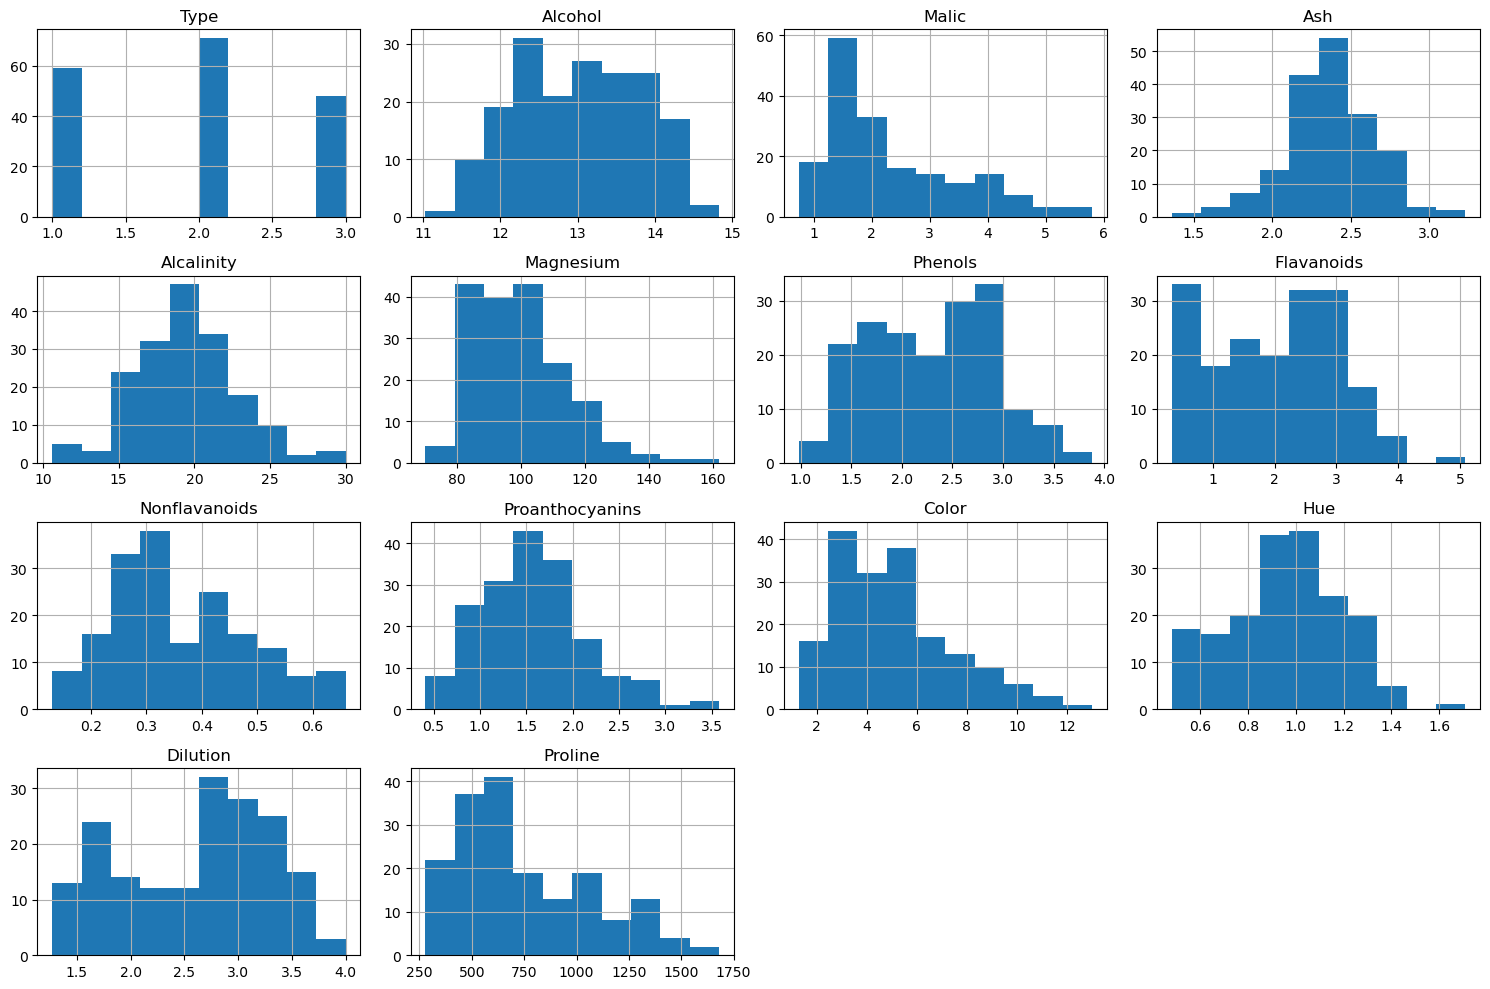

In [14]:
# Histograms
df.hist(figsize = (15,10))
plt.tight_layout()
plt.show()

Histogram Analysis                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
Alcohol, Ash, Hue, and Proanthocyanins show approximately normal distributions.
Malic Acid, Color Intensity, and Proline exhibit right-skewed distributions.
The feature Type contains three distinct classes (1, 2, and 3), indicating three wine categories.
The distributions show that features have different ranges and scales.

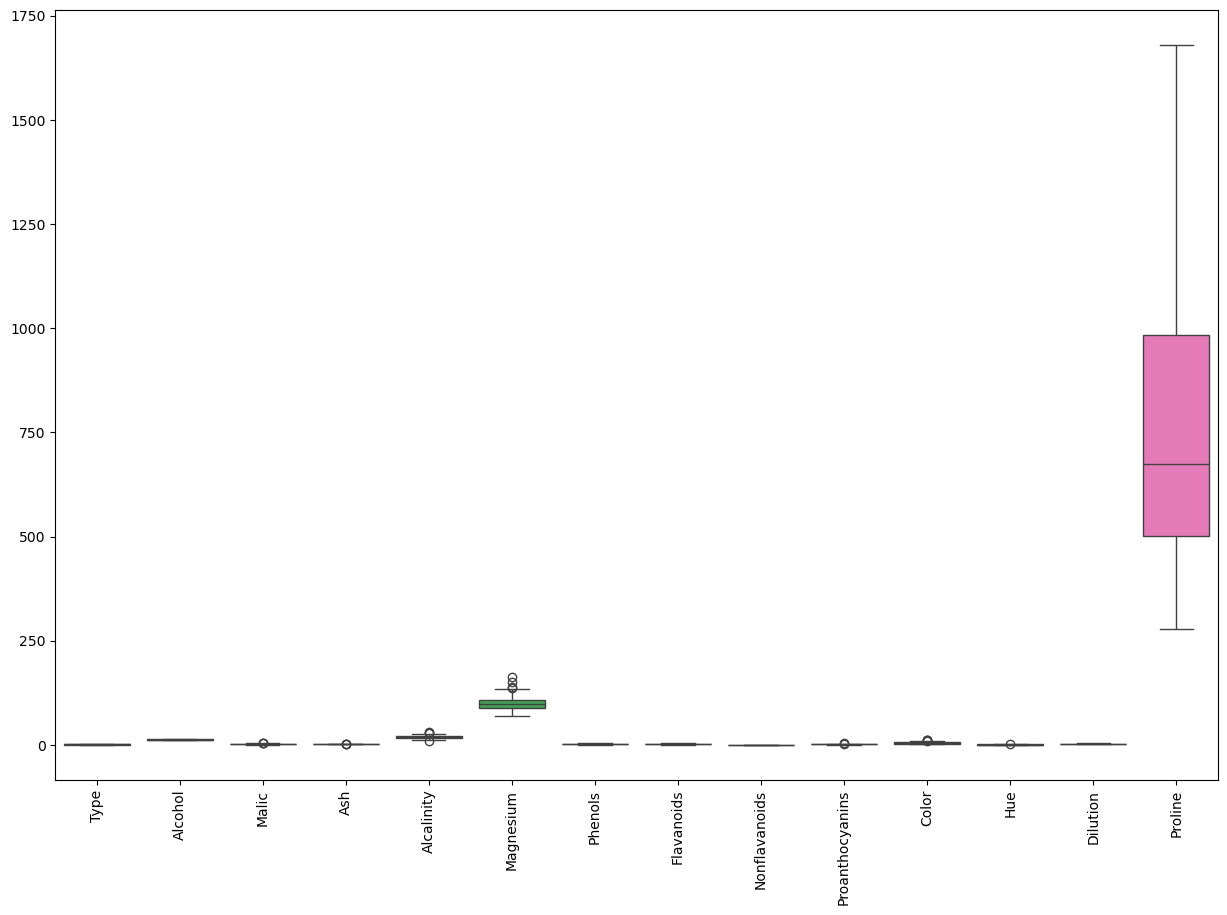

In [15]:
# Boxplot 
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

Box Plot Analysis                                                                                                                                      
Several features contain outliers, particularly:
Magnesium
Malic Acid
Proanthocyanins
Color Intensity
Proline has a much larger range than other features, causing it to dominate the box plot scale.
The presence of different scales suggests that feature standardization is necessary before PCA.

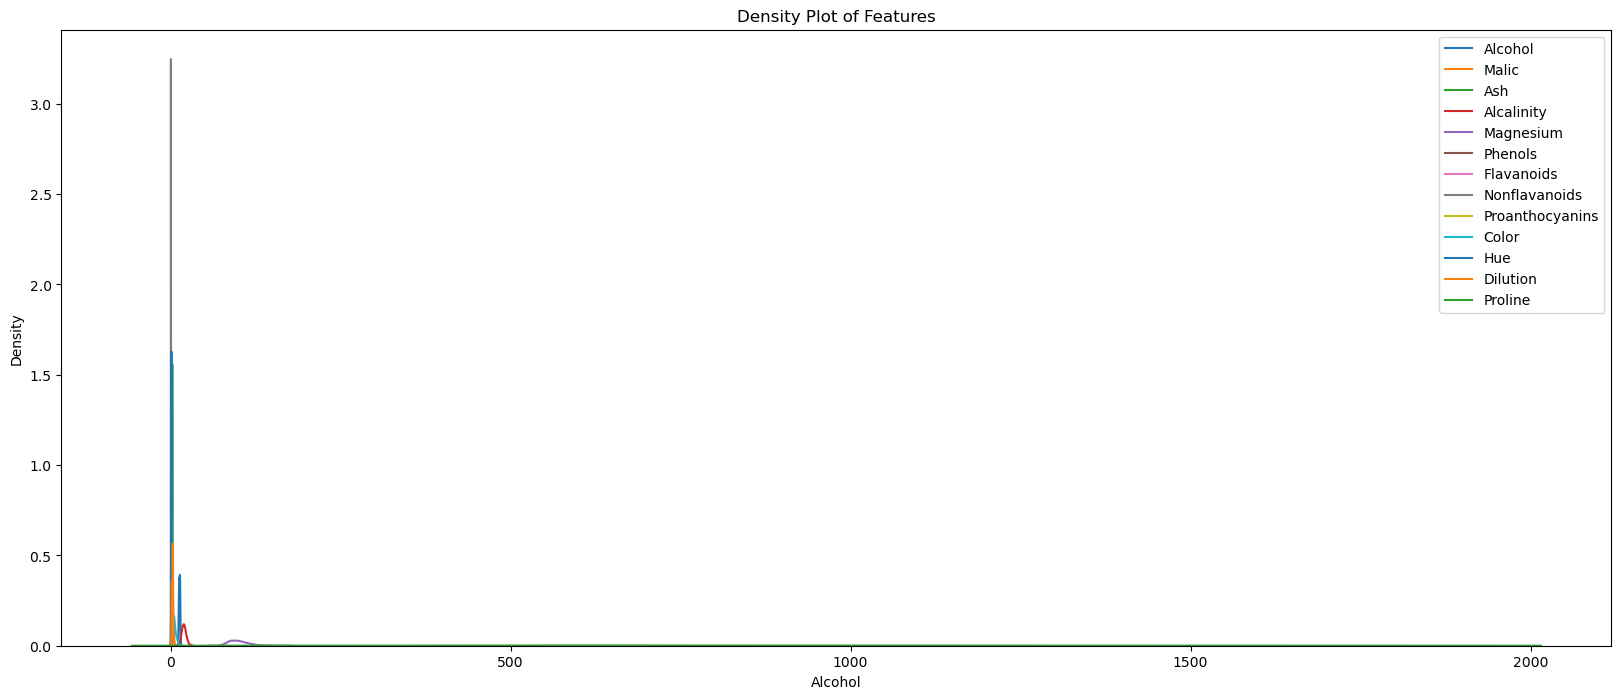

In [19]:
plt.figure(figsize=(20,8))
for col in df.columns[1:]:
    sns.kdeplot(df[col],label=col)

plt.legend()
plt.title("Density Plot of Features")
plt.show()

Density Plot Analysis                                                                                                                                   
Density plots show the probability distribution of each feature.
Because features have very different scales (especially Proline and Magnesium), some density curves appear compressed near zero.
The plot indicates that the dataset contains features with varying variances and distributions.
This further justifies applying StandardScaler before PCA.

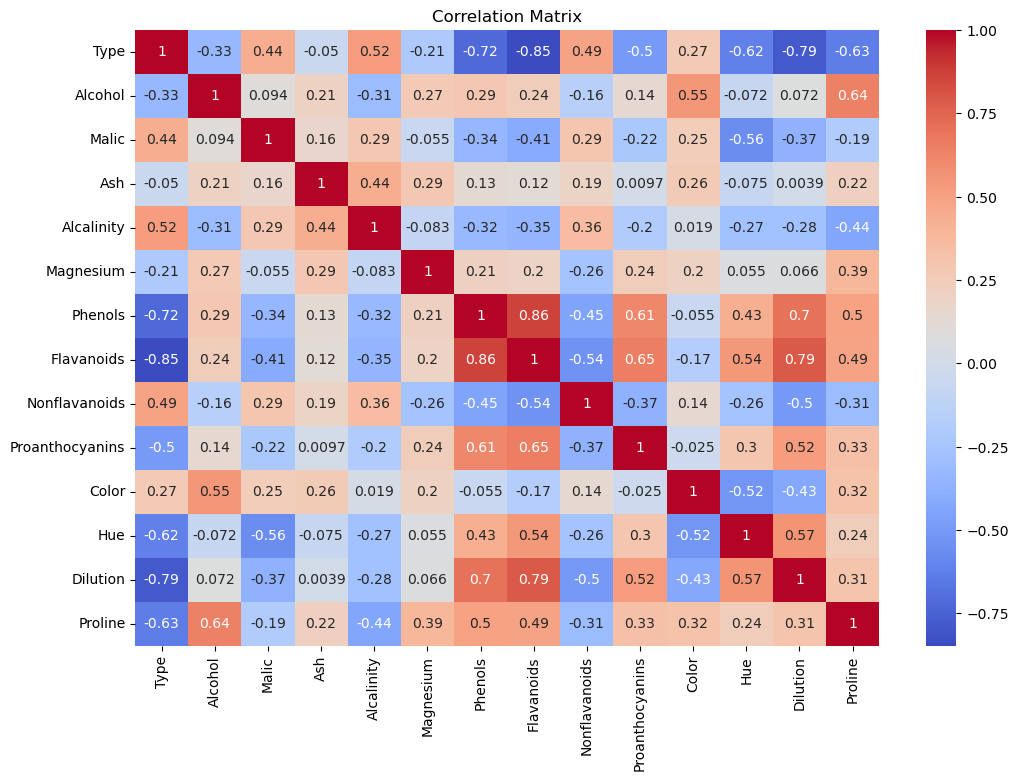

In [16]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True , cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Task 2: Dimensionality Reduction with PCA:

1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

In [22]:
X = df.drop('Type',axis=1)
y = df['Type']

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

In [27]:
#Apply PCA
from sklearn.decomposition import PCA 

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

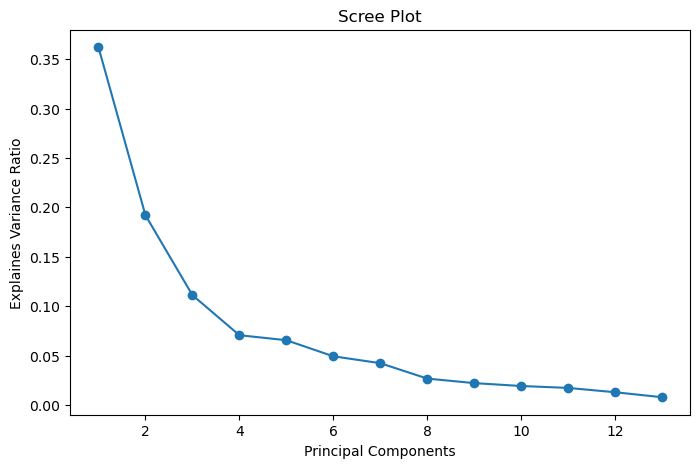

In [31]:
#Scree Plot
plt.figure(figsize=(8,5))
plt.plot(
    range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_,marker='o')

plt.xlabel("Principal Components")
plt.ylabel("Explaines Variance Ratio")
plt.title("Scree Plot")
plt.show()

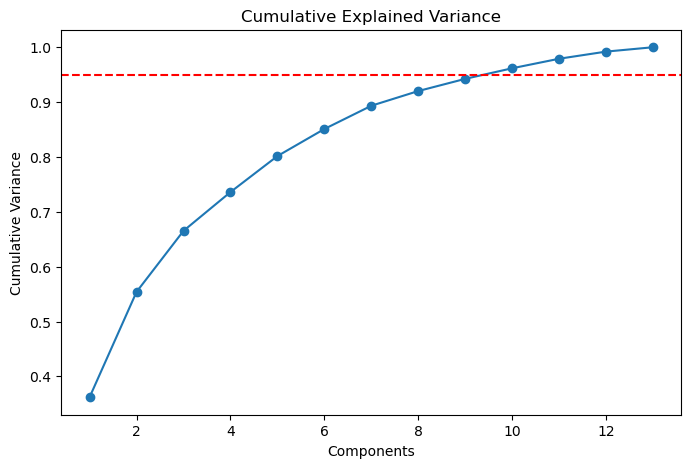

In [34]:
#Cumulative Explained Variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1,len(cum_var)+1),cum_var,marker='o')

plt.axhline(y=0.95,color='r',linestyle='--')

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Explained Variance")
plt.show()

3.	Transform the original dataset into the principal components.`

In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])

pca_df.head()

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


Task 3: Clustering with Original Data:

1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

In [39]:
from sklearn.cluster import KMeans

kmeans_original = KMeans(
    n_clusters= 3 ,
    random_state = 42
)

cluster_original = kmeans_original.fit_predict(X_scaled)

C:\Users\komal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


2.	Visualize the clustering results using appropriate plots.

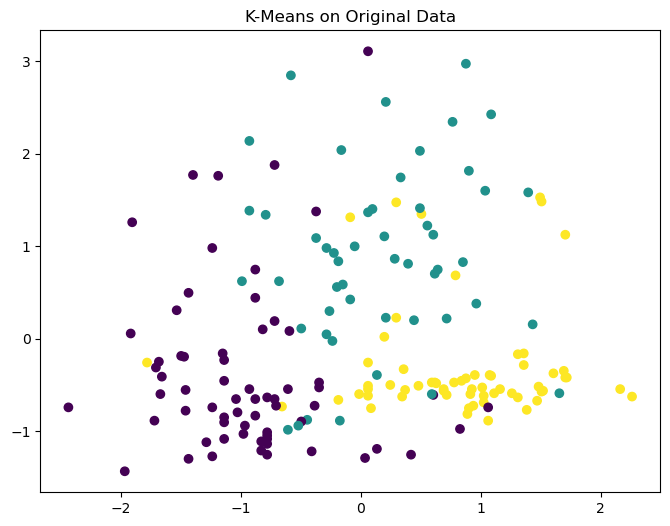

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=cluster_original,
    cmap='viridis'
)

plt.title("K-Means on Original Data")
plt.show()

3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

In [43]:
from sklearn.metrics import silhouette_score

sil_original = silhouette_score(
    X_scaled,
    cluster_original
)

print("Silhouette Score:",sil_original)

Silhouette Score: 0.2848589191898987


In [45]:
from sklearn.metrics import davies_bouldin_score

db_original = davies_bouldin_score(
    X_scaled,
    cluster_original
)

print("Davies-Bouldin Index:",db_original)

Davies-Bouldin Index: 1.3891879777181648


Task 4: Clustering with PCA Data:
    
1.	Apply the same clustering algorithm to the PCA-transformed dataset.

In [46]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\komal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


2.	Visualize the clustering results obtained from PCA-transformed data.

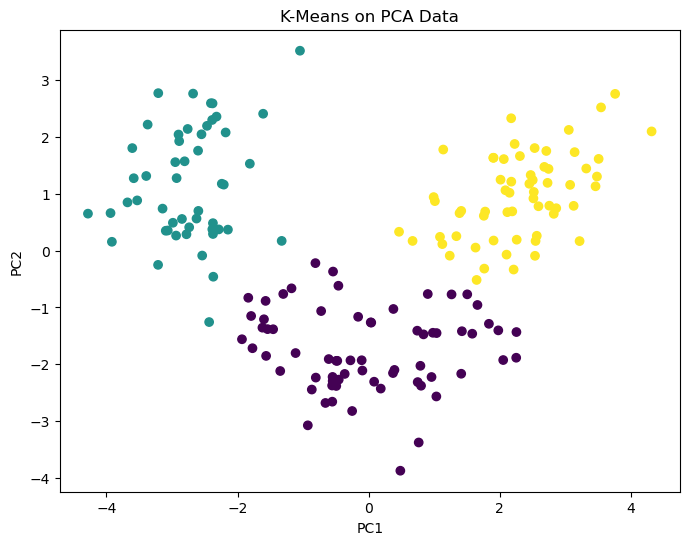

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=clusters_pca,
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("K-Means on PCA Data")
plt.show()

In [48]:
sil_pca = silhouette_score(
    X_pca,
    clusters_pca
)

print("Silhouette Score:",sil_pca)

Silhouette Score: 0.5601697480957202


In [49]:
db_pca = davies_bouldin_score(
    X_pca,
    clusters_pca
)

print("Davies-Bouldin Index:",db_pca)

Davies-Bouldin Index: 0.5977226208167409


Task 5: Comparison and Analysis:

1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.

In [50]:
comparison = pd.DataFrame({
    "Method":["Original Data","PCA Data"],
    "Silhouette Score":[sil_original,sil_pca],
    "Davies-Bouldin":[db_original,db_pca]
})

comparison

,Method,Silhouette Score,Davies-Bouldin
0,Original Data,0.284859,1.389188
1,PCA Data,0.560170,0.597723


2.	Discuss any similarities or differences observed in the clustering results.

    Similarities
  
Both methods identify similar cluster structures.                                                                                                      
The number of clusters remains the same.                                                                                                               
Major groupings of wine samples are preserved after PCA.

   Differences
   
PCA simplifies the dataset by reducing dimensionality.                                                                                                 
Cluster boundaries are more visible in PCA-transformed data.                                                                                           
Some information may be lost during dimensionality reduction.

3.	Reflect on the impact of dimensionality reduction on clustering performance.

PCA reduces redundant and correlated features.                                                                                                         
Noise in the dataset is minimized.                                                                                                                     
Computational complexity decreases.                                                                                                                    
Visualization becomes easier.                                                                                                                          
Clustering performance may improve due to reduced noise.

4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

Advantages of PCA

Faster computation.                                                                                                                                    
Reduced dimensionality.                                                                                                                                
Better visualization.                                                                                                                                  
Removes redundant information.    

Disadvantages of PCA

Some information loss.                                                                                                                                 
Principal components are less interpretable than original features.

Advantages of Original Data

Complete information is preserved.                                                                                                                     
Original feature meanings remain understandable.

Disadvantages of Original Data

Higher computational cost.                                                                                                                             
Difficult visualization in high dimensions.

Task 6: Conclusion and Insights

In [ ]:
1.	Summarize the key findings and insights from the assignment.

Exploratory Data Analysis revealed variations in feature distributions and the presence of outliers.
PCA successfully reduced the dimensionality of the Wine dataset from 13 features to 2 principal components.
K-Means clustering was applied to both the original and PCA-transformed datasets.
PCA enabled better visualization and simplified data representation.

In [ ]:
2.	Discuss the practical implications of using PCA and clustering in data analysis.

PCA is useful when dealing with high-dimensional datasets containing correlated features.
Clustering helps discover hidden patterns and group similar observations.
Combining PCA with clustering improves efficiency and visualization in real-world applications such as:
Customer segmentation
Medical diagnosis
Image recognition
Recommendation systems

In [ ]:
3.	Provide recommendations for when to use each technique based on the analysis conducted.

    
    